In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import uniform 
import random
from scipy.stats import rv_continuous
import time

In [2]:
import torch

#import autograd
#%set_env GEOMSTATS_BACKEND autograd
%set_env GEOMSTATS_BACKEND pytorch
import geomstats.backend as gs
from geomstats.geometry.euclidean import Euclidean
from geomstats.geometry.base import ImmersedSet
from geomstats.geometry.pullback_metric import (
    PullbackMetric,
    PullbackDiffeoMetric,
)

/home/ben/anaconda3/envs/BearLake/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


env: GEOMSTATS_BACKEND=pytorch


In [22]:
x=np.linspace(-1.0,-1/32,32)

xs = [t for t in x]
ys = [s for s in x]

dta = []
for t in xs:
    for s in ys:
        dta.extend([[t,s]])

X = np.array(dta)

In [23]:
#Xt = np.array([xs,ys])
Xt = X.transpose()
print(X.shape)

(1024, 2)


In [24]:
class Spiral(ImmersedSet):

    def __init__(self, equip=True):
        super().__init__(dim=2, equip=equip)

    def immersion(self, point):
        '''Immersion.'''
        t = point[...,0]
        s = point[...,1]
        return gs.stack(
            [
                t, #t*gs.cos(1*t),
                s, #t*gs.sin(1*t)
                t**2+s**2
            ],
            axis=-1,
        )

    def _define_embedding_space(self):
        return Euclidean(dim=self.dim + 1)



In [25]:
mySpiral = Spiral(equip=False)

mySpiral.equip_with_metric(PullbackMetric)

In [26]:
X_tens = torch.tensor(x).reshape((x.shape[0],1))

In [44]:
X_tens.shape

torch.Size([32, 1])

In [45]:
#mySpiral.metric.dist(X_tens[0],X_tens[1])

In [46]:
# we're executing a bit out of order: the training and test sets are defined below.
X_trainT = torch.tensor(X_train).float()
X_testT = torch.tensor(X_test).float()
t0 = time.time()
thedists = [mySpiral.metric.dist(X_trainT[0], x) for x in X_testT]
t1 = time.time()

In [47]:
print(t1-t0)

3128.174722671509


In [48]:
print(len(thedists))

512


In [30]:
#dists = torch.stack(thedists)

In [31]:
#plt.plot(dists)

In [32]:
'''myplot = plt.scatter(xs,ys,s=5,c=dists,cmap='jet')
plt.title("Distances Along the Archimedes Spiral")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar(myplot)
plt.show()'''

'myplot = plt.scatter(xs,ys,s=5,c=dists,cmap=\'jet\')\nplt.title("Distances Along the Archimedes Spiral")\nplt.xlabel("x")\nplt.ylabel("y")\nplt.colorbar(myplot)\nplt.show()'

In [33]:
y = [0 if t[0]**2+t[1]**2<1/np.sqrt(2) else 1 for t in X]

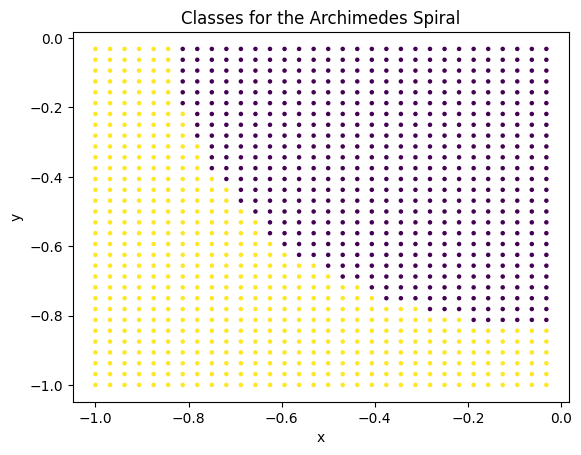

In [34]:
myplot2 = plt.scatter(Xt[0],Xt[1],s=5,c=y)
plt.title("Classes for the Archimedes Spiral")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [37]:
trainDS = pd.DataFrame(data=X_train)
trainDS.insert(loc=0, column='labels', value=y_train)

testDS = pd.DataFrame(data=X_test)
testDS.insert(loc=0, column='labels', value=y_test)

In [38]:
trainDS.to_csv("spiral_train.tsv",sep="\t",header=False,index=False)
testDS.to_csv("spiral_test.tsv",sep="\t",header=False,index=False)

In [39]:
import proxUtil

In [40]:
t2 = time.time()
proxUtil.getProx("spiral_train.tsv", "spiral_test.tsv", modelname="noimspartacus", distances=['maple'], getprox="false", memory='8g')
t3 = time.time()

reading file [spiral_test.tsv]:finished in 0:0:0.023
reading file [spiral_train.tsv]:finished in 0:0:0.005
Running on configurations...
Dataset: spiral_train.tsv, Training Data : 512x2 , Testing Data: 512x2, Train #Classes: 2, Test #Classes: 2
Repeats: 1 , Trees: 11 , Candidates per Split(r): 5
Output Dir: output, Export: 1, Verbosity: 1
Select DM per node: true , Shuffle Data: false, JVM WarmUp: false
----------------------------------------------------------------------------------------------------

-----------------Repetition No: 1 (spiral_train.tsv)   -----------------
Using: 8 MB, Free: 32 MB, Allocated Pool: 40 MB, Max Available: 8192 MB
core.ProximityForestResult@378fd1ac
0.1.2.3.4.5.6.7.8.9.10.
Using: 19 MB, Free: 21 MB, Allocated Pool: 40 MB, Max Available: 8192 MB
******
Training Time: 10987229.248561ms (3:3:7.229)
Prediction Time: 1103430.020771ms (0:18:23.430)
Correct(TP+TN): 506 vs Incorrect(FP+FN): 6
Accuracy: 0.98828125
Error Rate: 0.01171875
REPEAT:1 ,spiral_train.tsv,

In [41]:
print(t3-t2)

12092.008722305298


In [ ]:
#proxUtil.evalPF("spiral_test.tsv", modelname="noimspartacus")